## Chapter 5

#### example 1: exponential weighted average

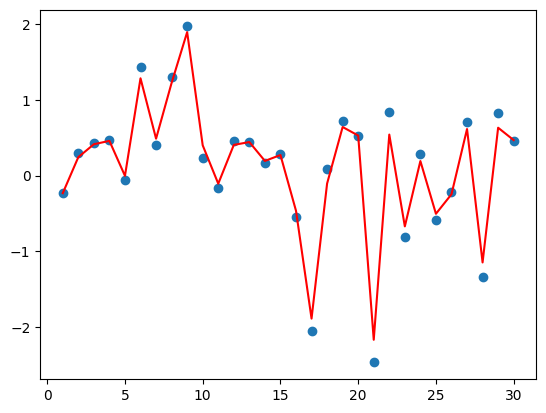

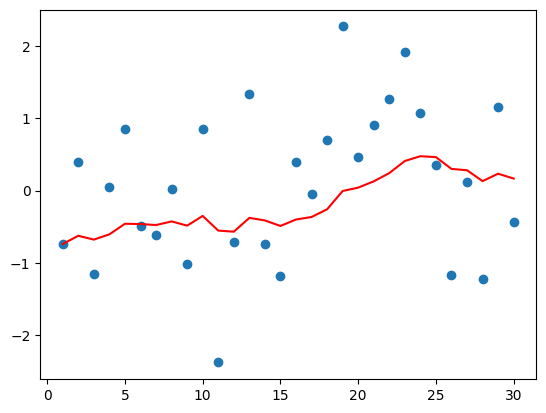

In [11]:
import torch
import matplotlib.pyplot as plt

def ewa(beta):
    t = torch.randn(size=[30, ])
    avg = []
    for i, temp in enumerate(t, 1):
        if i == 1:
            avg.append(temp)
        else:
            new_temp = beta * avg[i - 2] + (1 - beta) * temp
            avg.append(new_temp)

    days = torch.arange(1, 31, 1)
    plt.plot(days, avg, color='red')
    plt.scatter(days, t)
    plt.show()
    pass

if __name__ == '__main__':
    ewa(0.1)
    ewa(0.9)

#### example 2: momentum



- optimize gradient
- prepared for "flat" and "saddle point" (accumulated gradient)

#### example 3: adaGrad

- optimize learning rate
- formula: S_t = S_t-1 + G_t^2
- a = a / (sqrt(St) + c)  

#### example 4: RMSProp(Root Mean Square Propagation)

- optimize learning rate
- formula: S_t = (beta)S_t-1 + (1 - beta)G_t^2

#### example 5: Adam(Adaptive Moment Estimation)

- optimize both learning rate and gradient
- combine Momentum and RMSprop


##### application
- simple models and tasks: SGD or momentum
- complicated tasks or lots of data: Adam
- sparse data or text: Adagrad or RMSprop

In [ ]:
#demo for those 4 optimizer

import torch
import torch.nn as nn

def optimize_test():
    w = torch.tensor([1.0], requires_grad=True)

    for i in range(1, 20):
        loss = w ** 2 / 2.0
        #1
        optimizer = torch.optim.SGD(params=[w], lr=0.01, momentum=0.9)
        #2
        optimizer = torch.optim.Adagrad(params=[w], lr=0.01)
        #3
        optimizer = torch.optim.RMSprop(params=[w], lr=0.01, alpha=0.99)
        #4(beta=(gradient, learning_rate))
        optimizer = torch.optim.Adam(params=[w], lr=0.01, betas=(0.9, 0.999))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        print(f'i = {i}, w = {w}, gradient = {w.grad}')
    pass


if __name__ == "__main__":
    optimize_test()

i = 1, w = tensor([0.9900], requires_grad=True), gradient = tensor([1.])
i = 2, w = tensor([0.9801], requires_grad=True), gradient = tensor([0.9900])
i = 3, w = tensor([0.9703], requires_grad=True), gradient = tensor([0.9801])
i = 4, w = tensor([0.9606], requires_grad=True), gradient = tensor([0.9703])
i = 5, w = tensor([0.9510], requires_grad=True), gradient = tensor([0.9606])
i = 6, w = tensor([0.9415], requires_grad=True), gradient = tensor([0.9510])
i = 7, w = tensor([0.9321], requires_grad=True), gradient = tensor([0.9415])
i = 8, w = tensor([0.9227], requires_grad=True), gradient = tensor([0.9321])
i = 9, w = tensor([0.9135], requires_grad=True), gradient = tensor([0.9227])
i = 10, w = tensor([0.9044], requires_grad=True), gradient = tensor([0.9135])
i = 11, w = tensor([0.8953], requires_grad=True), gradient = tensor([0.9044])
i = 12, w = tensor([0.8864], requires_grad=True), gradient = tensor([0.8953])
i = 13, w = tensor([0.8775], requires_grad=True), gradient = tensor([0.8864])

#### example 6: learning rate dacay optimize method

- if learning rate is too high, loss function's oscillation will happen
- if learning rate decreases too slowly, loss function's convergence will be slow
- 3 learning rate decay method:
    + equal-spaced learning rate dacay: lr = lr * gamma (step-size-spaced)
    + appointed-spaced learning rate decay: appointed milestones
    + exponential learning rate decay: lr = lr * gamma ^ epoch
- application:
    + step: simple tasks and large dataset
    + multistep: high-steadiness-required tasks
    + exponential: high-accuracy-required tasks

C:\Users\mzr\AppData\Local\Temp\ipykernel_6720\3621924984.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


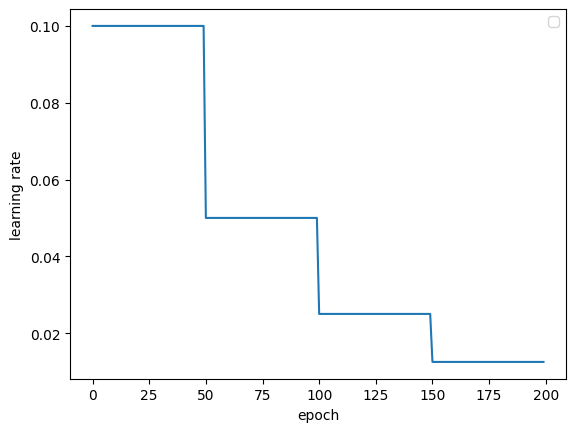

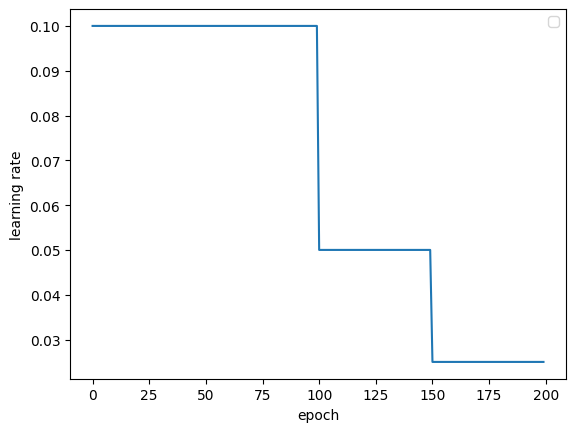

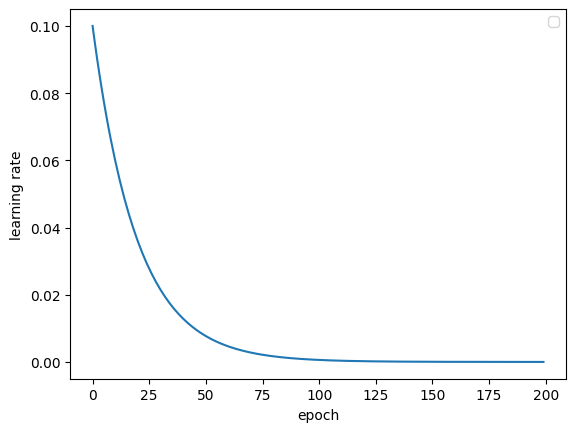

In [ ]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt

def lr_test(op):
    iter = 10
    epochs = 200
    y = torch.tensor(data=[0])
    x = torch.tensor(data=[1.0])
    w = torch.tensor([1.0], requires_grad=True)
    optimizer = optim.SGD(params=[w], lr=0.1, momentum=0.9)
    #set learning rate decay schedule
    if op == 1:
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)
    elif op == 2:
        scheduler = optim.lr_scheduler.MultiStepLR(optimizer,
                                                    milestones=[100, 150, 200],
                                                    gamma=0.5)
    elif op == 3:
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

    lr_list = []
    epoch_list = []

    for i in range(epochs):
        epoch_list.append(i)
        lr_list.append(scheduler.get_last_lr())

        for batch in range(iter):
            z = w * x
            loss = (z - y) ** 2
            optimizer.zero_grad()
            loss.backward()
            #update parameters
            optimizer.step()
        #update parameters
        scheduler.step()

    plt.plot(epoch_list, lr_list)
    plt.xlabel('epoch')
    plt.ylabel('learning rate')
    plt.legend()
    plt.show()
    pass

if __name__ == '__main__':
    lr_test(1)
    lr_test(2)
    lr_test(3)


#### example 7: regularization

- regularization: schedule for improving generalizing capacity
- adjust overfitting or underfitting
- dropout regularization:
    + deactivate some neurons with a possibility p (usually between 0.2 and 0.5)
    + amplify other neurons with a proportion 1 / (1 - p)
    + dropout will only be activated in training process
- L1 regularization: weights could be 0 (lower the dimension)
- L2 regularization: weights could be approximately equal to 0
- batch normalization: 
    + standardize -> zoom and translate
    + reduce inner convariance's excursion
    + usually apply for computer vision

In [22]:
import torch
from torch import nn

def reg():
    t = torch.randint(0, 10, size=(1, 4)).float()
    linear1 = nn.Linear(in_features=4, out_features=4)
    l1 = linear1(t)
    print(f'l1 = {l1}')
    output = torch.relu(l1)
    print(f'output = {output}')
    dropout = nn.Dropout(p=0.5)
    output = dropout(output)
    print(f'dropout = {output}')
    pass

if __name__ == '__main__':
    reg()

l1 = tensor([[1.0148, 6.2571, 2.8229, 2.5266]], grad_fn=<AddmmBackward0>)
output = tensor([[1.0148, 6.2571, 2.8229, 2.5266]], grad_fn=<ReluBackward0>)
dropout = tensor([[2.0296, 0.0000, 0.0000, 5.0533]], grad_fn=<MulBackward0>)
